In [1]:
# # Step 1: Import Libraries
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Display settings
# pd.set_option('display.max_columns', None)
# sns.set(style="whitegrid")

# # Step 2: Load Dataset
# # Replace with your file path
# df = pd.read_csv('data/raw/insurance_claims.csv')

# # Step 3: Initial Data Overview
# print("Shape of dataset:", df.shape)
# df.head()

# # Step 4: Data Info and Summary
# df.info()
# df.describe(include='all')

# # Step 5: Check for Missing Values
# print("\nMissing values in each column:")
# print(df.isnull().sum())

# # Step 6: Target Variable Distribution
# # Replace 'target_column' with your actual target column name (e.g., 'fraud_reported' or 'claim_approved')
# target_col = 'fraud_reported'
# sns.countplot(x=target_col, data=df)
# plt.title("Target Variable Distribution")
# plt.show()

# # Step 7: Categorical Feature Distributions
# categorical_cols = df.select_dtypes(include='object').columns.tolist()
# categorical_cols = [col for col in categorical_cols if col != target_col]

# for col in categorical_cols:
#     plt.figure(figsize=(8, 4))
#     sns.countplot(x=col, data=df, order=df[col].value_counts().index)
#     plt.xticks(rotation=45)
#     plt.title(f'Distribution of {col}')
#     plt.tight_layout()
#     plt.show()

# # Step 8: Numerical Feature Distributions
# numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# df[numerical_cols].hist(figsize=(15, 10), bins=30)
# plt.suptitle("Numerical Feature Distributions", fontsize=16)
# plt.show()

# # Step 9: Correlation Heatmap
# plt.figure(figsize=(12, 8))
# corr_matrix = df[numerical_cols].corr()
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title("Correlation Matrix")
# plt.show()

# # Step 10: Outlier Detection (Optional)
# # Using boxplots
# for col in numerical_cols:
#     plt.figure(figsize=(8, 4))
#     sns.boxplot(x=df[col])
#     plt.title(f'Boxplot of {col}')
#     plt.show()


# Import Statements

In [3]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load csv file

In [4]:
df = pd.read_csv("../data/raw_data/insurance fraud claims.csv")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [5]:
df.shape

(1000, 40)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [7]:
df.describe(include="all")

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
count,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000.000000,1000.000000,1.000000e+03,1000.000000,...,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000,1000,1000.000000,1000,0.0
unique,NaN,NaN,NaN,951,3,3,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,NaN,14,39,NaN,2,NaN
top,NaN,NaN,NaN,1992-08-05,OH,250/500,NaN,NaN,NaN,NaN,...,?,NaN,NaN,NaN,NaN,Saab,RAM,NaN,N,NaN
freq,NaN,NaN,NaN,3,352,351,NaN,NaN,NaN,NaN,...,343,NaN,NaN,NaN,NaN,80,43,NaN,753,NaN
mean,203.954000,38.948000,546238.648000,NaN,NaN,NaN,1136.000000,1256.406150,1.101000e+06,501214.488000,...,NaN,52761.94000,7433.420000,7399.570000,37928.950000,NaN,NaN,2005.103000,NaN,NaN
std,115.113174,9.140287,257063.005276,NaN,NaN,NaN,611.864673,244.167395,2.297407e+06,71701.610941,...,NaN,26401.53319,4880.951853,4824.726179,18886.252893,NaN,NaN,6.015861,NaN,NaN
min,0.000000,19.000000,100804.000000,NaN,NaN,NaN,500.000000,433.330000,-1.000000e+06,430104.000000,...,NaN,100.00000,0.000000,0.000000,70.000000,NaN,NaN,1995.000000,NaN,NaN
25%,115.750000,32.000000,335980.250000,NaN,NaN,NaN,500.000000,1089.607500,0.000000e+00,448404.500000,...,NaN,41812.50000,4295.000000,4445.000000,30292.500000,NaN,NaN,2000.000000,NaN,NaN
50%,199.500000,38.000000,533135.000000,NaN,NaN,NaN,1000.000000,1257.200000,0.000000e+00,466445.500000,...,NaN,58055.00000,6775.000000,6750.000000,42100.000000,NaN,NaN,2005.000000,NaN,NaN
75%,276.250000,44.000000,759099.750000,NaN,NaN,NaN,2000.000000,1415.695000,0.000000e+00,603251.000000,...,NaN,70592.50000,11305.000000,10885.000000,50822.500000,NaN,NaN,2010.000000,NaN,NaN


In [10]:
missing = df.isna().sum()
missing[missing>0]

authorities_contacted      91
_c39                     1000
dtype: int64

## Target Column Distibution

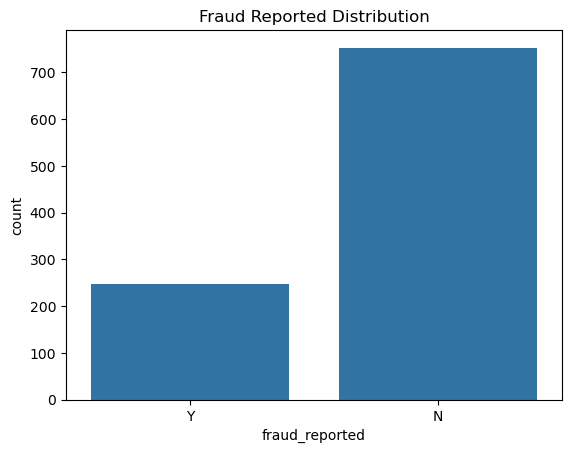

In [11]:
sns.countplot(x="fraud_reported", data=df)
plt.title("Fraud Reported Distribution")
plt.show()

## Categorical column exploration

In [21]:
categorical_cols = df.select_dtypes(include=["object"]).columns.to_list()
categorical_cols.remove("fraud_reported")

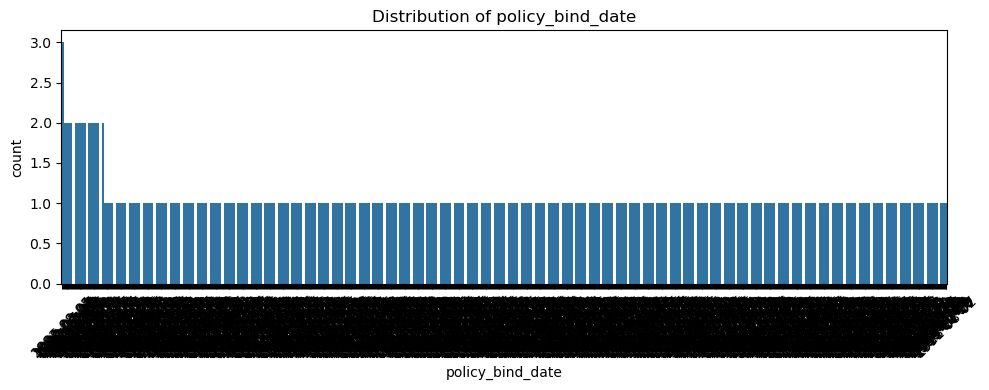

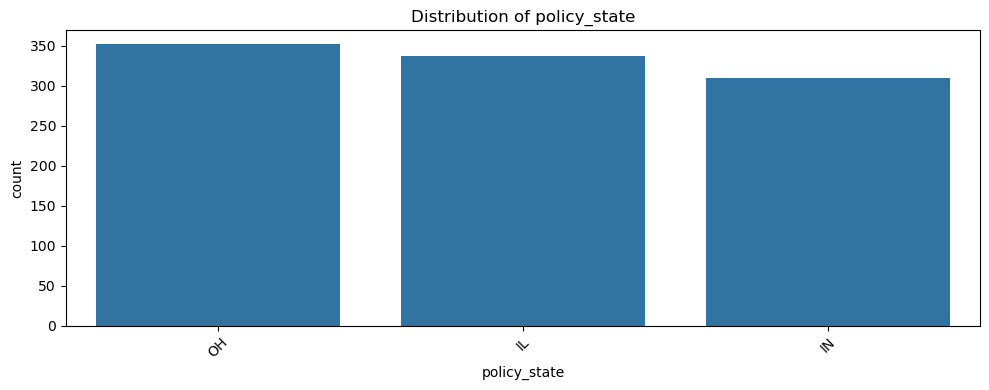

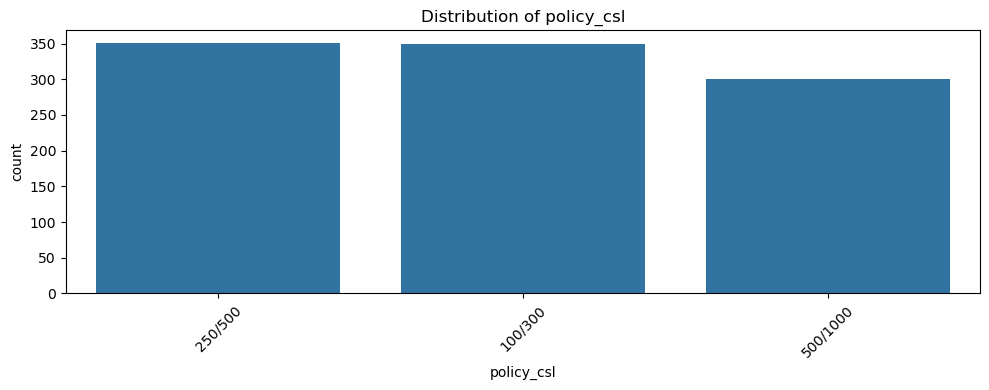

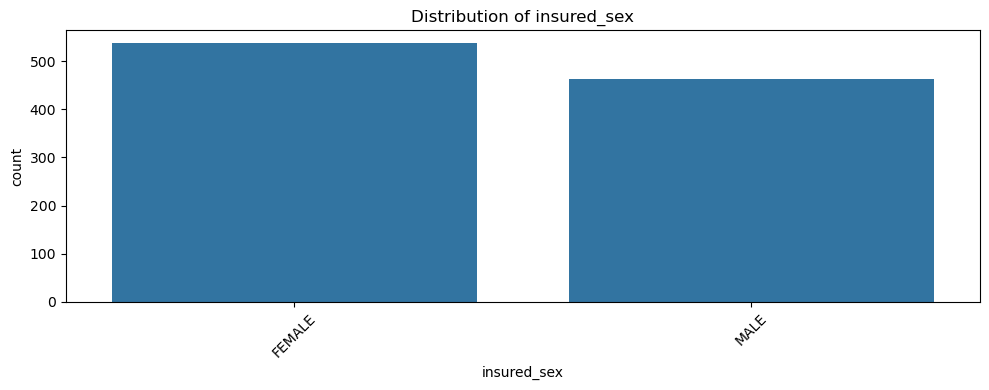

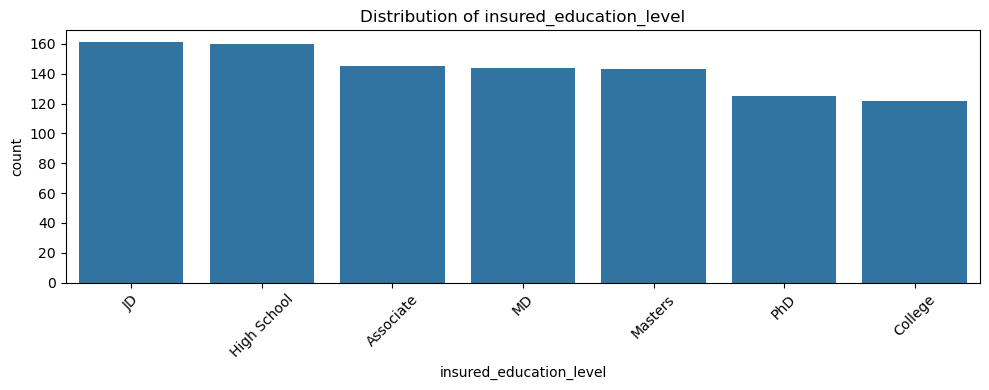

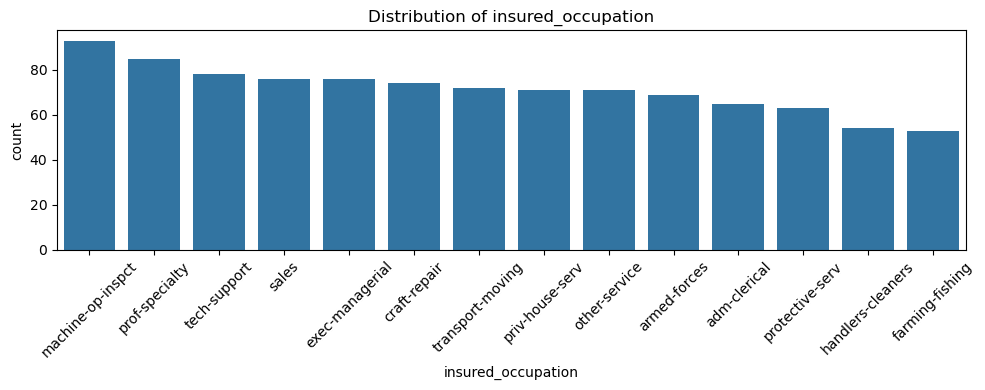

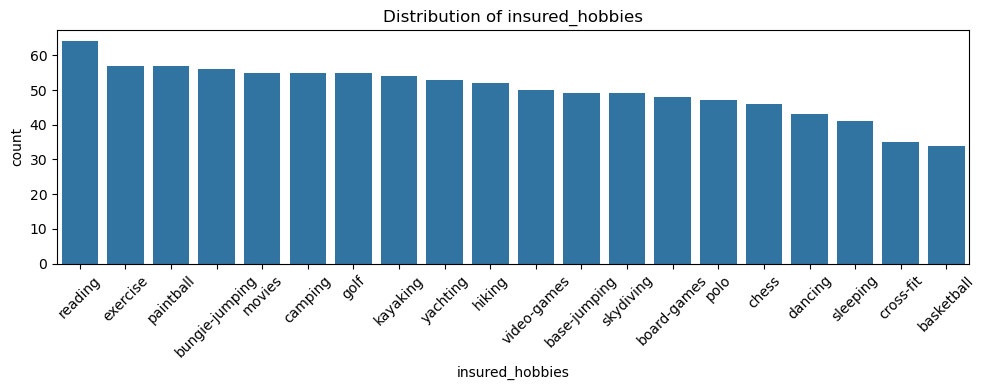

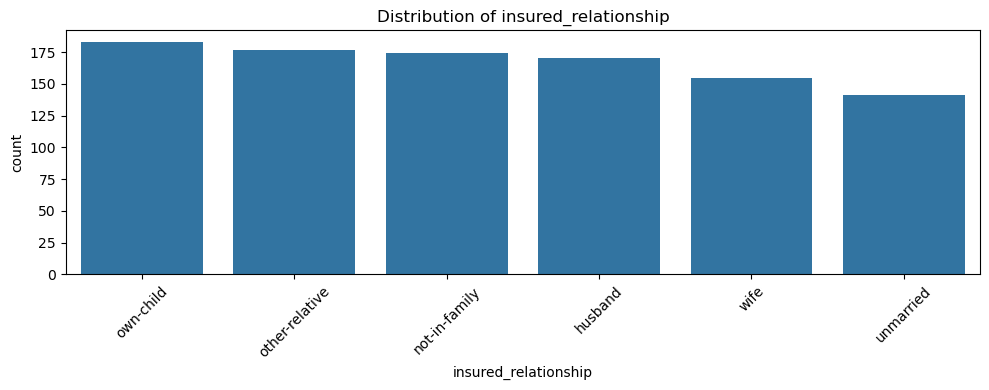

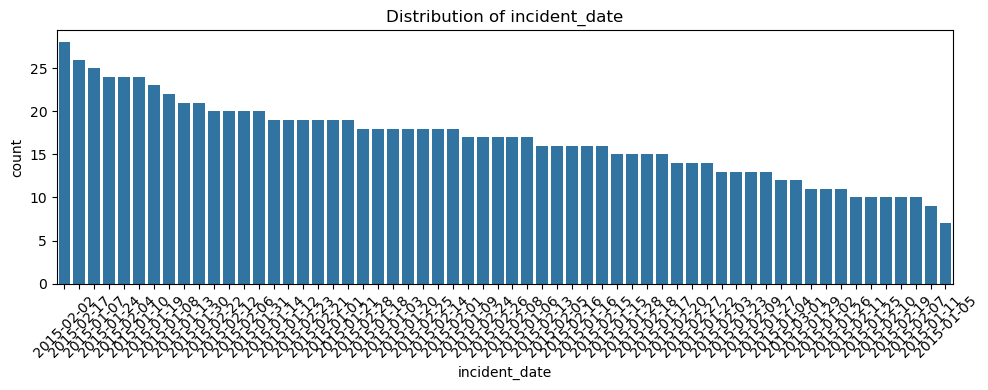

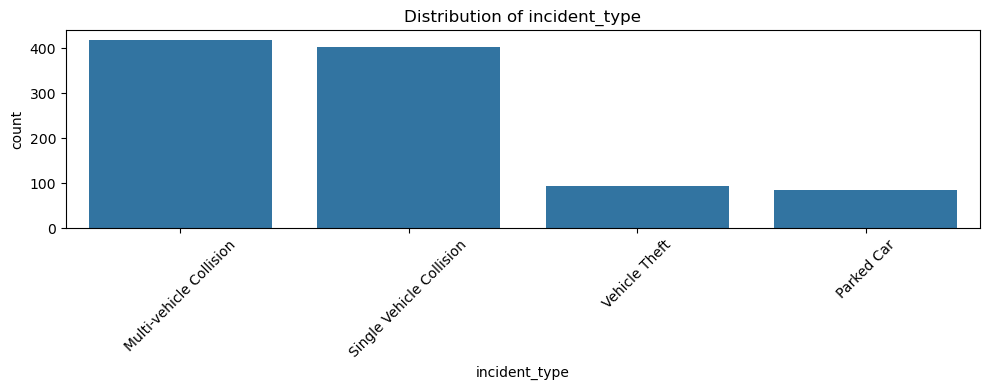

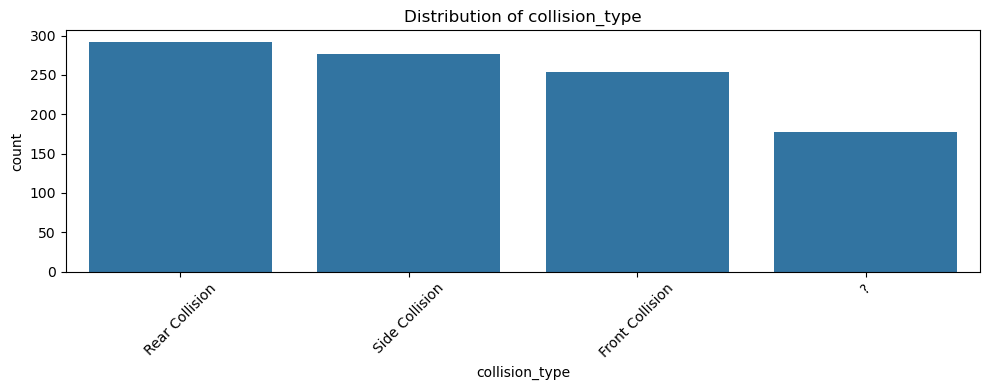

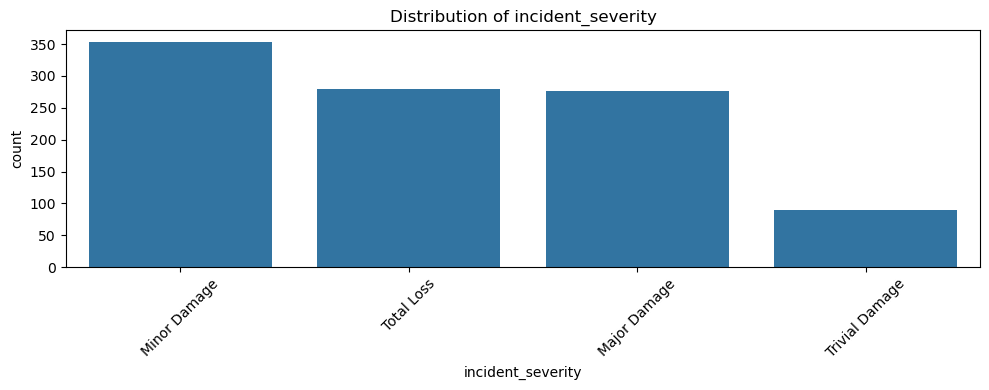

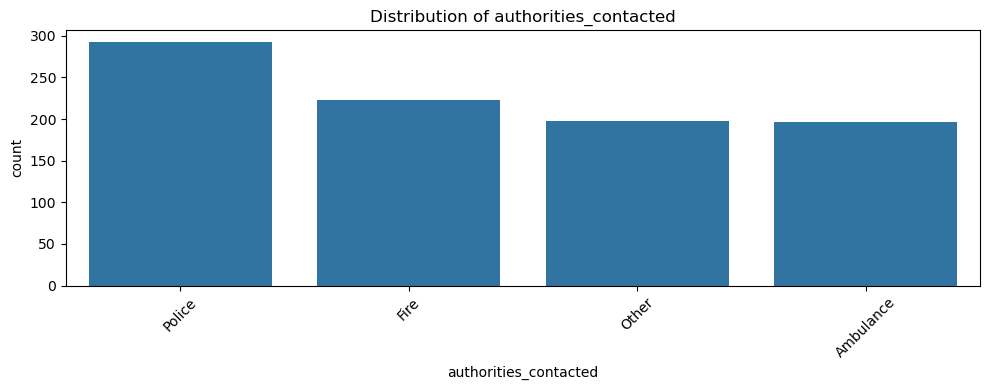

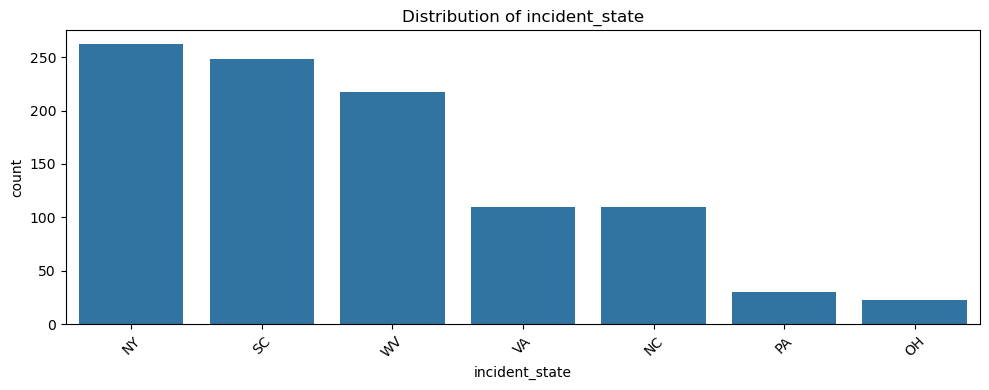

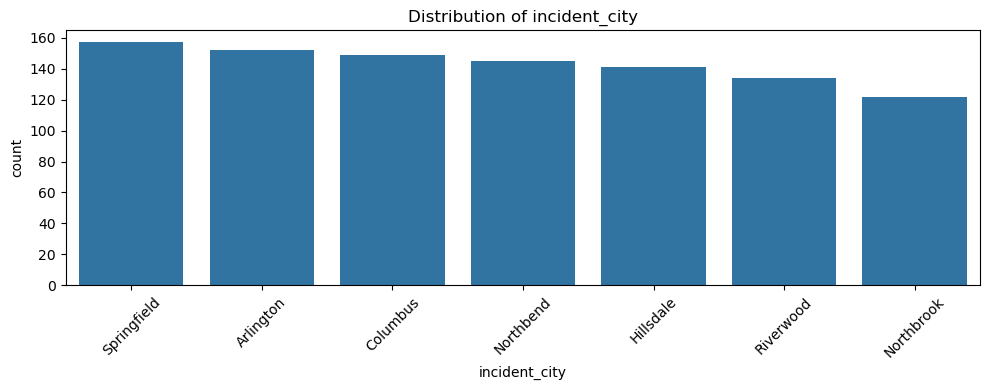

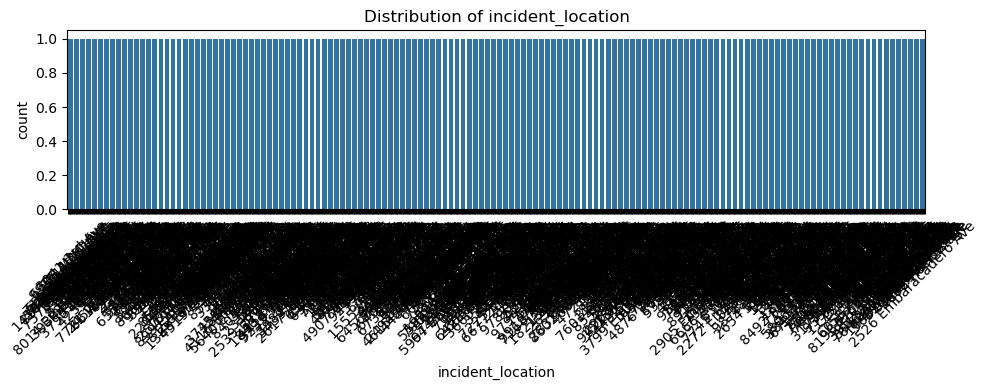

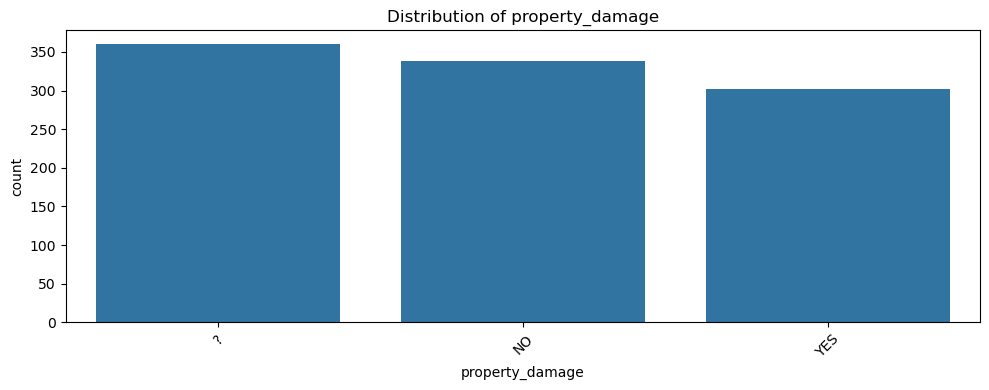

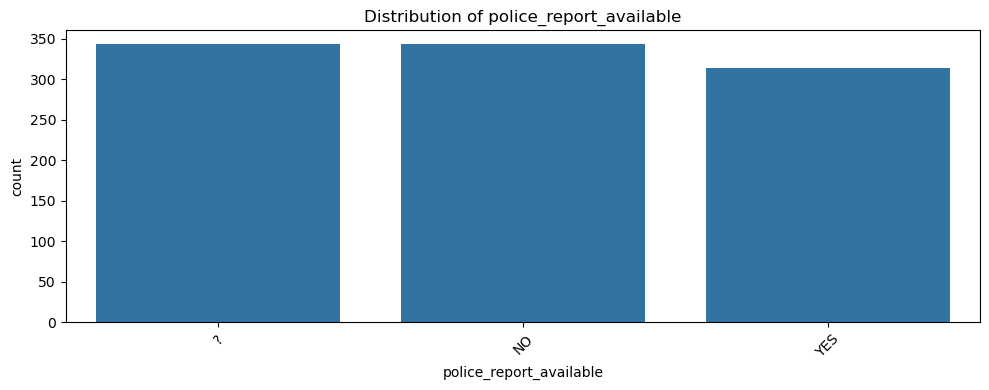

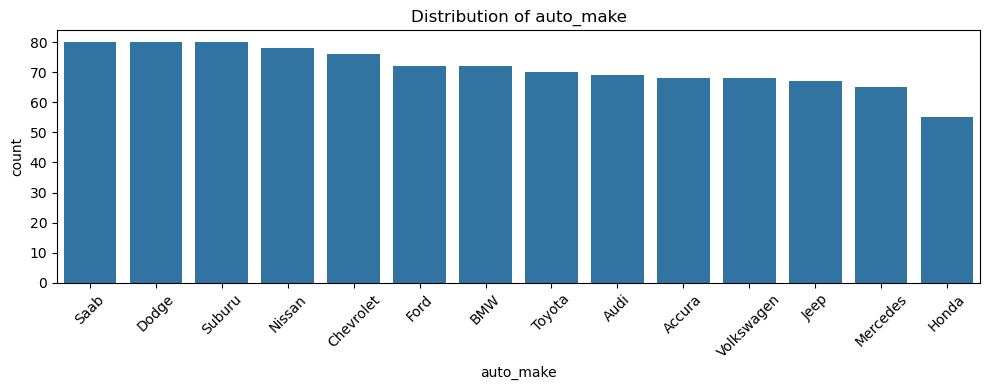

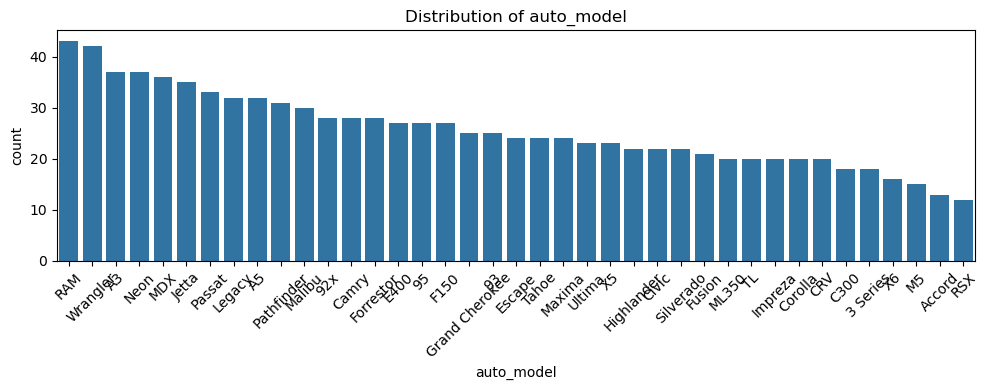

In [34]:
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

## Numerical column exploration

In [38]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.to_list()

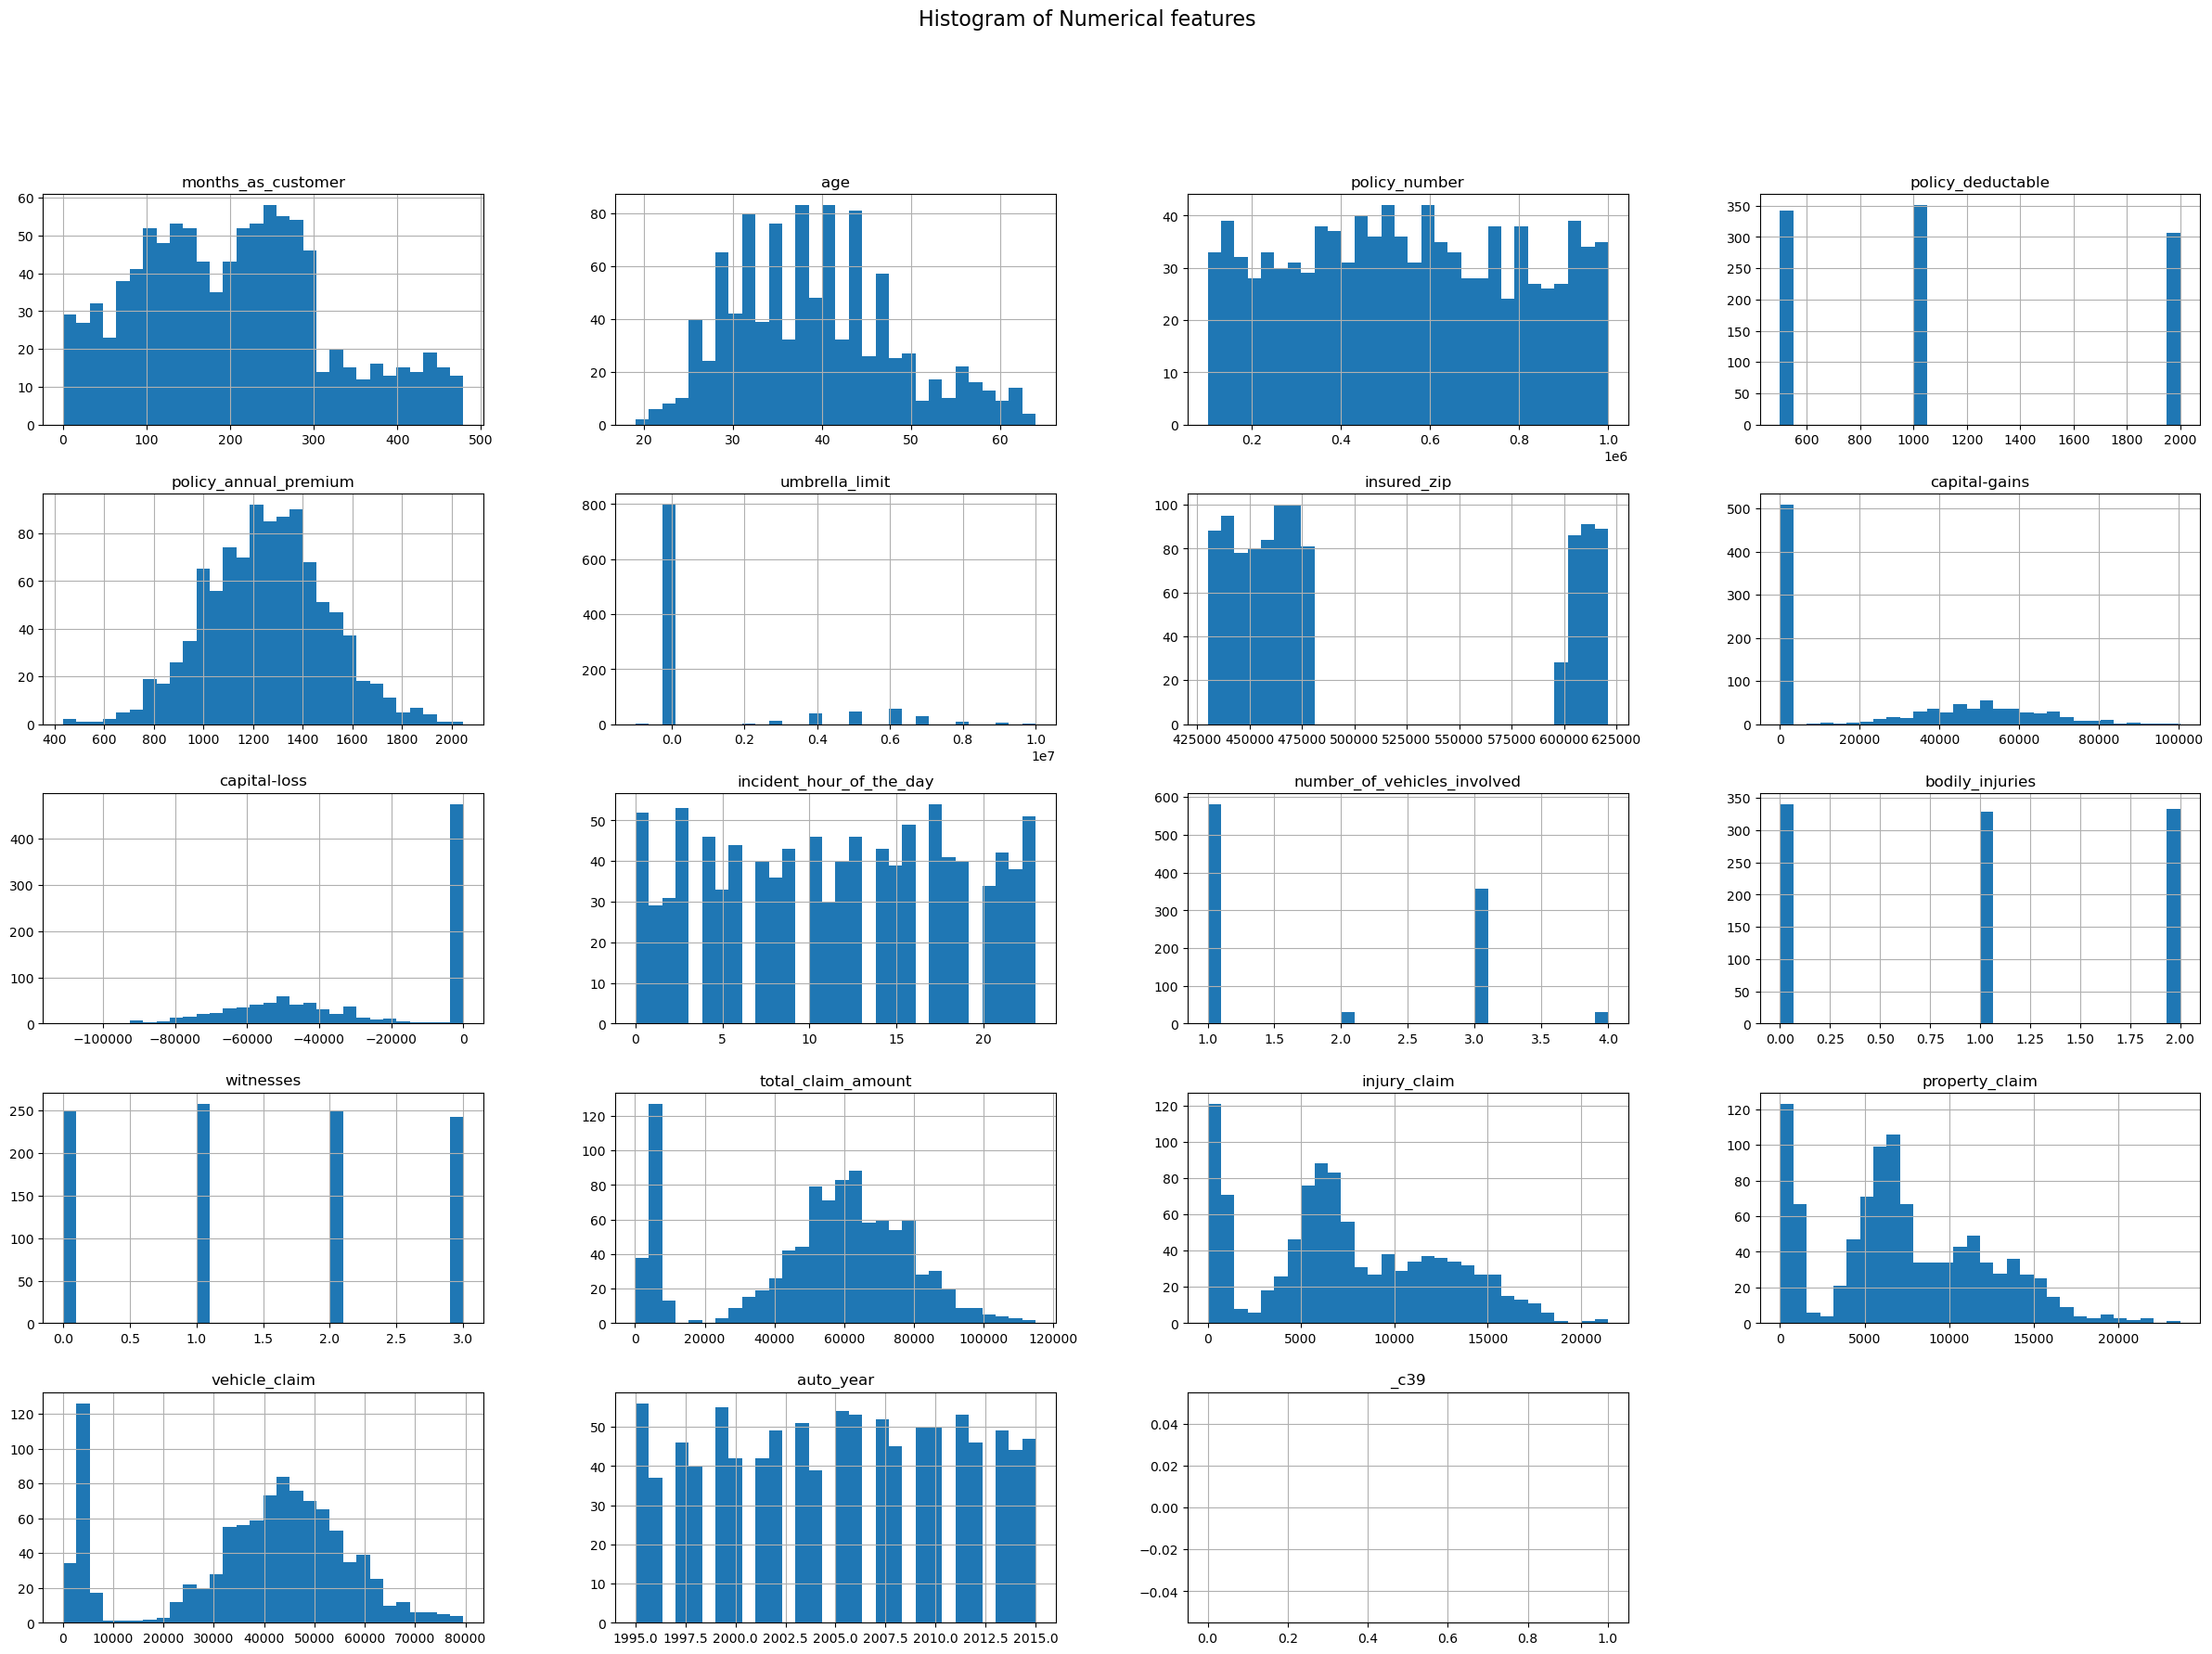

In [44]:
df[numerical_cols].hist(figsize=(30, 20), bins=30)
plt.suptitle("Histogram of Numerical features", fontsize=16)
plt.show()

## Correlation heatmap

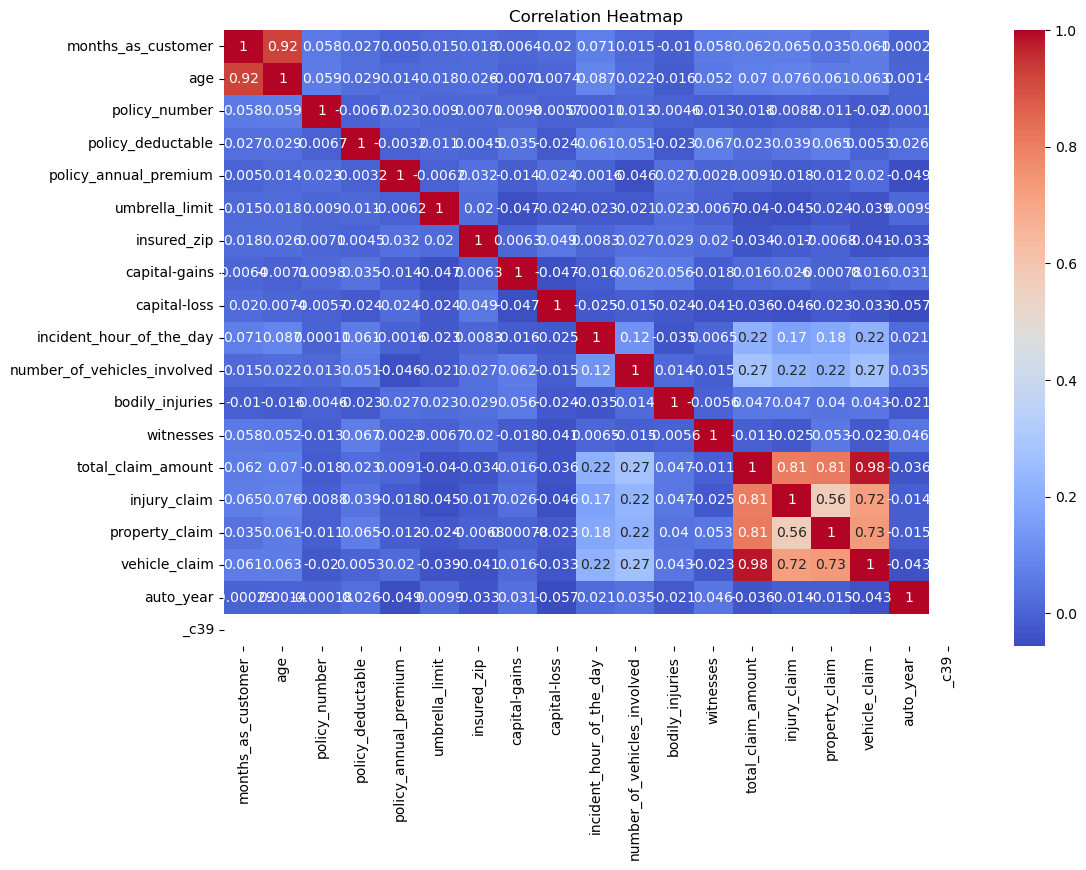

In [49]:
plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()